<a href="https://colab.research.google.com/github/TerePainecura/TRABAJO-U3-HOUSE-PRICES-CLUSTERING/blob/main/Sumativo_U3_HousePrices_Clustering_TeresaPainecura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Sumativo Unidad 3 — Clustering aplicado a House Prices

**Asignatura:** Machine Learning  
**Dataset:** House Prices – Advanced Regression Techniques  
**Objetivo:** aplicar técnicas de análisis no supervisado para identificar agrupamientos naturales en viviendas y evaluar si dichos clusters se relacionan con la variable conocida `SalePrice`.


## Punto 1. Preparación de datos

In [29]:
## 1.1 Importación de librerías y carga del dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/TerePainecura/TRABAJO-U3-HOUSE-PRICES-CLUSTERING/main/train.csv"

df = pd.read_csv(url)

print("Dimensiones iniciales del dataset:", df.shape)
df.head()

Dimensiones iniciales del dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
## 1.2 Identificación de la variable objetivo

# En análisis no supervisado, SalePrice NO se usa para entrenar los modelos de clustering.
# Se conserva aparte para interpretar posteriormente si los clusters tienen sentido respecto al precio.

y_price = df["SalePrice"]

print("Variable objetivo conservada para interpretación posterior:")
print(y_price.head())

Variable objetivo conservada para interpretación posterior:
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [4]:
## 1.3 Copia de trabajo

df_clean = df.copy()

print("Copia de trabajo creada:", df_clean.shape)

Copia de trabajo creada: (1460, 81)


In [5]:
## 1.4 Tratamiento de valores faltantes que representan ausencia real de característica

cols_none = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

for col in cols_none:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("None")

print("Valores faltantes tratados como ausencia real de característica.")

Valores faltantes tratados como ausencia real de característica.


In [6]:
## 1.5 Imputación de variables numéricas

num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Imputación numérica finalizada.")

Imputación numérica finalizada.


In [7]:
## 1.6 Imputación de variables categóricas

cat_cols = df_clean.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Imputación categórica finalizada.")

Imputación categórica finalizada.


In [8]:
## 1.7 Verificación final de valores faltantes

total_missing = df_clean.isnull().sum().sum()

print("Valores faltantes restantes:", total_missing)

Valores faltantes restantes: 0


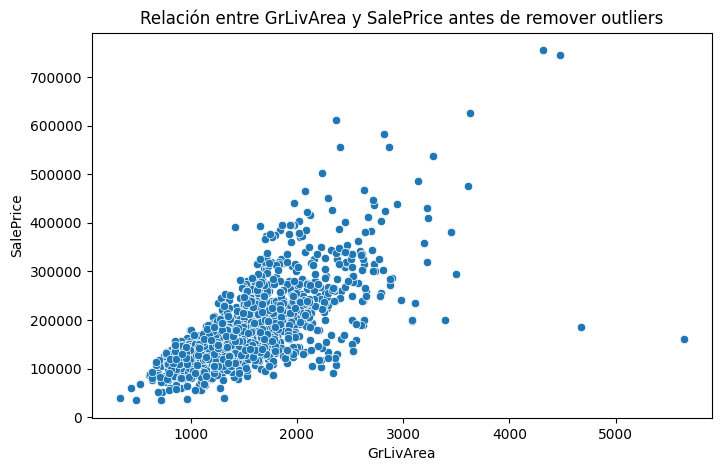

Dimensiones luego de remover outliers: (1458, 81)


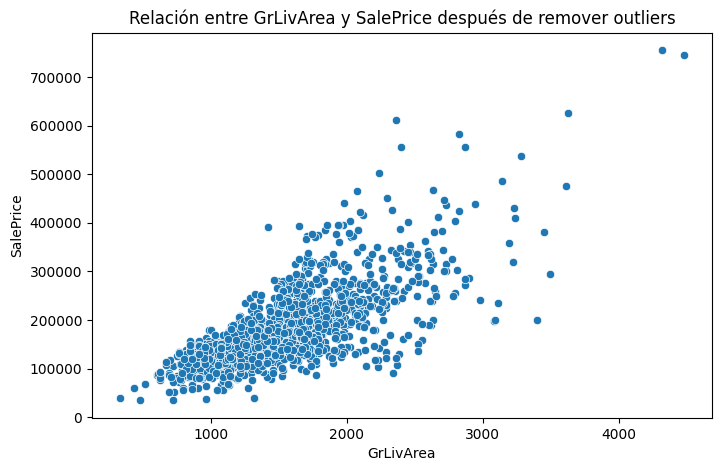

In [9]:
## 1.8 Tratamiento de outliers extremos

plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean["GrLivArea"], y=df_clean["SalePrice"])
plt.title("Relación entre GrLivArea y SalePrice antes de remover outliers")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

# Eliminación de outliers extremos identificados en el trabajo previo
df_clean = df_clean[~((df_clean["GrLivArea"] > 4000) & (df_clean["SalePrice"] < 300000))]

print("Dimensiones luego de remover outliers:", df_clean.shape)

plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean["GrLivArea"], y=df_clean["SalePrice"])
plt.title("Relación entre GrLivArea y SalePrice después de remover outliers")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

In [10]:
## 1.9 Separación de variable objetivo para clustering

# Se guarda SalePrice para interpretación posterior.
y_price = df_clean["SalePrice"]

# Se elimina SalePrice del entrenamiento porque el análisis es no supervisado.
# También se elimina Id porque es solo un identificador.
X_cluster = df_clean.drop(columns=["SalePrice", "Id"], errors="ignore")

print("Base para clustering sin variable objetivo:", X_cluster.shape)

Base para clustering sin variable objetivo: (1458, 79)


In [11]:
## 1.10 One-Hot Encoding

X_ohe = pd.get_dummies(X_cluster, drop_first=True)

print("Dimensiones después de One-Hot Encoding:", X_ohe.shape)
X_ohe.head()

Dimensiones después de One-Hot Encoding: (1458, 258)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [12]:
## 1.11 Normalización de datos

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_ohe)

df_scaled = pd.DataFrame(
    X_scaled,
    columns=X_ohe.columns,
    index=X_ohe.index
)

print("Dimensiones de la base normalizada:", df_scaled.shape)
df_scaled.head()

Dimensiones de la base normalizada: (1458, 258)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.073426,-0.221328,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,0.465863,-0.303537
1,-0.871868,0.491760,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,0.465863,-0.303537
2,0.073426,-0.078710,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,0.465863,-0.303537
3,0.309749,-0.459024,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,-2.146554,-0.303537
4,0.073426,0.681917,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,0.465863,-0.303537


In [13]:
## 1.12 Resumen final del Punto 1

resumen_punto_1 = pd.DataFrame({
    "Etapa": [
        "Dataset original",
        "Base limpia",
        "Base para clustering sin SalePrice",
        "Base con One-Hot Encoding",
        "Base normalizada"
    ],
    "Filas": [
        df.shape[0],
        df_clean.shape[0],
        X_cluster.shape[0],
        X_ohe.shape[0],
        df_scaled.shape[0]
    ],
    "Columnas": [
        df.shape[1],
        df_clean.shape[1],
        X_cluster.shape[1],
        X_ohe.shape[1],
        df_scaled.shape[1]
    ]
})

resumen_punto_1

,Etapa,Filas,Columnas
0,Dataset original,1460,81
1,Base limpia,1458,81
2,Base para clustering sin SalePrice,1458,79
3,Base con One-Hot Encoding,1458,258
4,Base normalizada,1458,258


## Punto 2. Experimento con y sin PCA

En este punto se construyen dos representaciones del dataset: una base sin PCA, correspondiente a la base normalizada completa, y una base con PCA, donde se reduce la dimensionalidad conservando la mayor cantidad posible de información. El objetivo es comparar si la reducción de dimensionalidad mejora o no la estructura de agrupamiento.

In [14]:
## 2.1 Base sin PCA

# La base sin PCA corresponde a la base previamente limpia, codificada y normalizada.
# Esta base conserva todas las variables generadas después del One-Hot Encoding.

X_sin_pca = df_scaled.copy()

print("Dimensiones de la base sin PCA:", X_sin_pca.shape)
X_sin_pca.head()

Dimensiones de la base sin PCA: (1458, 258)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.073426,-0.221328,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,0.465863,-0.303537
1,-0.871868,0.491760,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,0.465863,-0.303537
2,0.073426,-0.078710,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,0.465863,-0.303537
3,0.309749,-0.459024,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,-2.146554,-0.303537
4,0.073426,0.681917,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,-0.288867,...,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.05245,-0.091098,-0.117933,0.465863,-0.303537


In [15]:
## 2.2 Aplicación inicial de PCA para analizar varianza explicada

from sklearn.decomposition import PCA

# Se ajusta PCA con todas las componentes posibles para analizar la varianza explicada.
pca_full = PCA()
pca_full.fit(X_sin_pca)

# Varianza explicada por cada componente
explained_variance = pca_full.explained_variance_ratio_

# Varianza explicada acumulada
cumulative_variance = np.cumsum(explained_variance)

print("Cantidad total de componentes posibles:", len(cumulative_variance))
print("Varianza acumulada con las primeras 10 componentes:")
print(cumulative_variance[:10])

Cantidad total de componentes posibles: 258
Varianza acumulada con las primeras 10 componentes:
[0.06651368 0.09793635 0.12584472 0.1488194  0.17027593 0.18933767
 0.20480777 0.2195854  0.23281983 0.24537105]


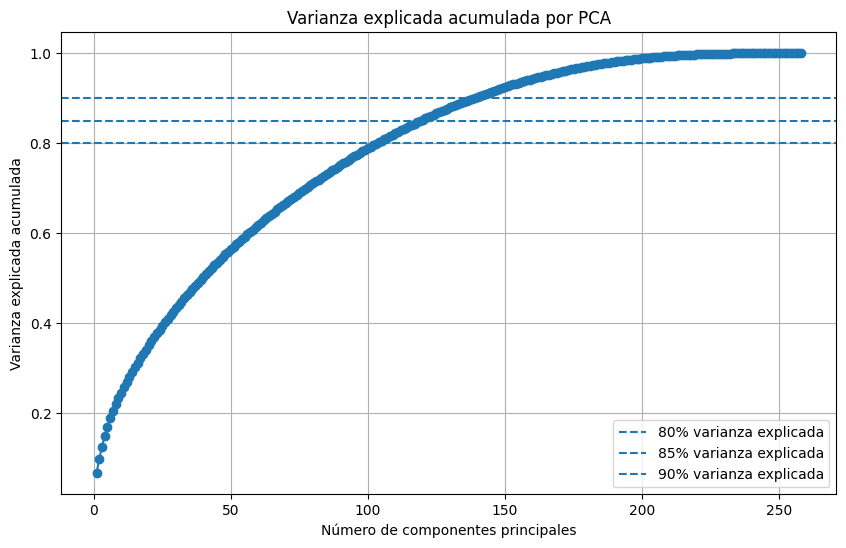

In [16]:
## 2.3 Gráfico de varianza explicada acumulada

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.80, linestyle="--", label="80% varianza explicada")
plt.axhline(y=0.85, linestyle="--", label="85% varianza explicada")
plt.axhline(y=0.90, linestyle="--", label="90% varianza explicada")

plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
## 2.4 Selección del número mínimo de componentes

# Se selecciona el número mínimo de componentes que explica al menos el 90% de la varianza.
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Número mínimo de componentes para explicar el 90% de la varianza:", n_components_90)
print("Varianza explicada acumulada:", cumulative_variance[n_components_90 - 1])

Número mínimo de componentes para explicar el 90% de la varianza: 139
Varianza explicada acumulada: 0.9013939942360982


In [18]:
## 2.5 Construcción de la base con PCA

pca = PCA(n_components=n_components_90)

X_pca = pca.fit_transform(X_sin_pca)

df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(n_components_90)],
    index=X_sin_pca.index
)

print("Dimensiones de la base con PCA:", df_pca.shape)
df_pca.head()

Dimensiones de la base con PCA: (1458, 139)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC130,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138,PC139
0,4.363767,-1.793165,-0.251635,-0.953178,-1.323918,-2.421841,-0.570806,-1.514274,-0.406952,1.688524,...,-0.286579,-0.110944,-0.251712,0.018699,0.057682,-0.345892,-0.293724,-0.238588,-0.128235,0.169904
1,0.128238,2.989811,0.343630,-0.827698,0.600245,-0.435780,1.038420,-1.112345,-0.197539,-0.683199,...,1.163348,-1.528727,-0.795400,-0.280773,1.224130,1.967288,0.229150,-1.910543,0.250857,0.175631
2,5.110012,-1.159425,0.145048,-0.195184,-0.656909,-2.377837,0.063514,-2.049939,-0.606944,1.530866,...,0.178776,-0.092284,-0.244209,-0.357254,0.100586,-0.793418,-0.661917,-0.148327,0.113552,0.364301
3,-0.949033,-0.462342,-0.856774,3.158923,-0.873618,1.156338,0.748145,-0.846774,-0.182475,-0.847033,...,0.959380,0.568505,1.328400,-0.738346,1.716965,0.159626,0.752311,0.225476,0.098319,-0.189710
4,6.676083,-0.667239,0.626756,2.155452,0.251208,-3.041955,-0.285371,-1.148650,-1.363606,2.255864,...,0.392195,0.576368,0.223824,-0.445115,-1.677784,0.316617,0.612669,0.797802,-0.848121,-0.107266


In [19]:
## 2.6 Comparación de dimensiones con y sin PCA

comparacion_pca = pd.DataFrame({
    "Base": ["Sin PCA", "Con PCA"],
    "Filas": [X_sin_pca.shape[0], df_pca.shape[0]],
    "Columnas": [X_sin_pca.shape[1], df_pca.shape[1]],
    "Descripción": [
        "Base normalizada completa después de One-Hot Encoding",
        "Base reducida mediante componentes principales"
    ]
})

comparacion_pca

,Base,Filas,Columnas,Descripción
0,Sin PCA,1458,258,Base normalizada completa después de One-Hot E...
1,Con PCA,1458,139,Base reducida mediante componentes principales


In [20]:
## 2.7 Verificación del criterio PCA seleccionado

print("Número de componentes para 90% de varianza explicada:", n_components_90)

comparacion_pca

Número de componentes para 90% de varianza explicada: 139


,Base,Filas,Columnas,Descripción
0,Sin PCA,1458,258,Base normalizada completa después de One-Hot E...
1,Con PCA,1458,139,Base reducida mediante componentes principales


### Interpretación del Punto 2

En este punto se construyeron dos representaciones del dataset para comparar el comportamiento de los algoritmos de clustering: una base sin PCA y una base con PCA.

La base sin PCA corresponde a la matriz completa después de la limpieza de datos, la codificación mediante One-Hot Encoding y la normalización. Esta representación conserva toda la información disponible del dataset, pero presenta una alta dimensionalidad debido al aumento de columnas generado por la transformación de variables categóricas.

Posteriormente, se aplicó PCA con el objetivo de reducir la dimensionalidad del dataset mediante componentes principales. Para definir el número de componentes se analizó el gráfico de varianza explicada acumulada. En dicho gráfico se observa que la curva aumenta con mayor rapidez al inicio, lo que indica que las primeras componentes concentran una parte relevante de la información. Sin embargo, a medida que se agregan más componentes, la curva comienza a aplanarse, mostrando rendimientos decrecientes: cada componente adicional aporta menos información nueva.

Para este trabajo se utilizó como criterio conservar al menos el 90% de la varianza explicada acumulada. Esta decisión permite mantener una proporción alta de la información original, reduciendo al mismo tiempo la cantidad de variables utilizadas por los algoritmos. De esta forma, se evita una reducción excesiva que podría eliminar información relevante para la formación de clusters.

La comparación entre la base sin PCA y la base con PCA permitirá evaluar si la reducción de dimensionalidad mejora la calidad del clustering o si, por el contrario, la base original normalizada conserva una estructura más útil para los algoritmos no supervisados. Esta comparación es importante porque PCA puede reducir ruido y redundancia, pero no garantiza automáticamente mejores agrupamientos.

## Punto 3. Challenge entre algoritmos de clustering

En este punto se realiza un benchmarking entre distintos algoritmos de clustering, considerando modelos basados en distancia y modelos basados en densidad. El objetivo es comparar su comportamiento en dos representaciones del dataset: una base sin PCA y una base con PCA.

Esta comparación permite evaluar qué algoritmo identifica agrupamientos más consistentes y si la reducción de dimensionalidad mediante PCA mejora la estructura de los clusters.

In [21]:
## 3.1 Importación de librerías para clustering

from sklearn.cluster import KMeans, AgglomerativeClustering, Birch, DBSCAN, OPTICS
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings("ignore")

In [22]:
## 3.2 Función para evaluar modelos de clustering

def evaluar_clustering(X, labels, nombre_modelo, tipo_base):
    """
    Evalúa un modelo de clustering usando métricas internas.
    Se excluyen casos donde el modelo genera un solo cluster o todos los puntos como ruido.
    """

    labels_unicos = set(labels)

    # Eliminar etiqueta -1 del conteo si corresponde a ruido en DBSCAN/OPTICS
    labels_sin_ruido = [label for label in labels_unicos if label != -1]

    n_clusters = len(labels_sin_ruido)
    n_ruido = list(labels).count(-1) if -1 in labels_unicos else 0

    if n_clusters < 2:
        return {
            "Base": tipo_base,
            "Modelo": nombre_modelo,
            "Clusters": n_clusters,
            "Ruido": n_ruido,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan,
            "Comentario": "No evaluable: menos de 2 clusters"
        }

    try:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)

        return {
            "Base": tipo_base,
            "Modelo": nombre_modelo,
            "Clusters": n_clusters,
            "Ruido": n_ruido,
            "Silhouette": sil,
            "Davies-Bouldin": db,
            "Calinski-Harabasz": ch,
            "Comentario": "Evaluado correctamente"
        }

    except Exception as e:
        return {
            "Base": tipo_base,
            "Modelo": nombre_modelo,
            "Clusters": n_clusters,
            "Ruido": n_ruido,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan,
            "Comentario": f"Error en evaluación: {e}"
        }

In [31]:
## 3.3 Búsqueda preliminar del mejor número de clusters con KMeans

def buscar_mejor_k(X, tipo_base, k_range=range(2, 11)):
    resultados_k = []

    for k in k_range:
        modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = modelo.fit_predict(X)

        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)

        resultados_k.append({
            "Base": tipo_base,
            "K": k,
            "Silhouette": sil,
            "Davies-Bouldin": db,
            "Calinski-Harabasz": ch
        })

    return pd.DataFrame(resultados_k)

k_sin_pca = buscar_mejor_k(X_sin_pca, "Sin PCA")
k_con_pca = buscar_mejor_k(df_pca, "Con PCA")

resultados_k = pd.concat([k_sin_pca, k_con_pca], ignore_index=True)

resultados_k

,Base,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,Sin PCA,2,0.050741,3.698913,80.313910
1,Sin PCA,3,0.054004,3.426437,60.739647
2,Sin PCA,4,0.058021,3.010753,54.841981
3,Sin PCA,5,-0.006508,3.825760,46.401075
4,Sin PCA,6,0.002104,4.080098,41.044485
5,Sin PCA,7,0.050037,3.274885,37.869604
6,Sin PCA,8,0.002203,4.176498,35.847386
7,Sin PCA,9,0.002177,3.418473,33.257693
8,Sin PCA,10,-0.002074,3.115417,31.449821
9,Con PCA,2,0.058507,3.463497,89.744396


In [32]:
## 3.4 Selección del mejor K según Silhouette

mejor_k_sin_pca = int(
    k_sin_pca.sort_values(by="Silhouette", ascending=False).iloc[0]["K"]
)

mejor_k_con_pca = int(
    k_con_pca.sort_values(by="Silhouette", ascending=False).iloc[0]["K"]
)

print("Mejor K sin PCA:", mejor_k_sin_pca)
print("Mejor K con PCA:", mejor_k_con_pca)

Mejor K sin PCA: 4
Mejor K con PCA: 3


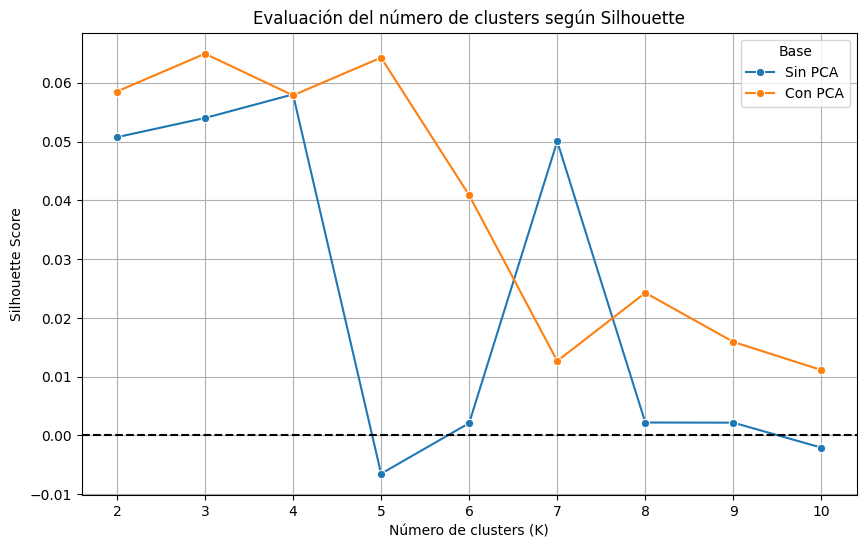

In [37]:
## 3.5 Visualización de Silhouette según número de clusters

plt.figure(figsize=(10,6))

sns.lineplot(
    data=resultados_k,
    x="K",
    y="Silhouette",
    hue="Base",
    marker="o"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Evaluación del número de clusters según Silhouette")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [41]:
## 3.6 Función para ejecutar challenge entre algoritmos

def ejecutar_challenge(X, tipo_base, n_clusters):
    resultados = []

    # 1. KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X)
    resultados.append(evaluar_clustering(X, labels_kmeans, "KMeans", tipo_base))

    # 2. Agglomerative Clustering
    agglomerative = AgglomerativeClustering(n_clusters=n_clusters)
    labels_agg = agglomerative.fit_predict(X)
    resultados.append(evaluar_clustering(X, labels_agg, "Agglomerative Clustering", tipo_base))

    # 3. Birch
    birch = Birch(n_clusters=n_clusters)
    labels_birch = birch.fit_predict(X)
    resultados.append(evaluar_clustering(X, labels_birch, "Birch", tipo_base))

    # 4. DBSCAN
    dbscan = DBSCAN(eps=3, min_samples=5)
    labels_dbscan = dbscan.fit_predict(X)
    resultados.append(evaluar_clustering(X, labels_dbscan, "DBSCAN", tipo_base))

    # 5. OPTICS
    optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
    labels_optics = optics.fit_predict(X)
    resultados.append(evaluar_clustering(X, labels_optics, "OPTICS", tipo_base))

    # 6. Gaussian Mixture
    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type="diag",
        reg_covar=1e-6,
        random_state=42
    )
    labels_gmm = gmm.fit_predict(X)
    resultados.append(evaluar_clustering(X, labels_gmm, "Gaussian Mixture", tipo_base))

    return pd.DataFrame(resultados)

In [39]:
## 3.7 Challenge con base sin PCA

resultados_sin_pca = ejecutar_challenge(
    X_sin_pca,
    "Sin PCA",
    mejor_k_sin_pca
)

resultados_sin_pca

,Base,Modelo,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz,Comentario
0,Sin PCA,KMeans,4,0,0.058021,3.010753,54.841981,Evaluado correctamente
1,Sin PCA,Agglomerative Clustering,4,0,0.030149,4.366251,45.458644,Evaluado correctamente
2,Sin PCA,Birch,4,0,0.020875,4.316465,45.361436,Evaluado correctamente
3,Sin PCA,DBSCAN,1,1453,NaN,NaN,NaN,No evaluable: menos de 2 clusters
4,Sin PCA,OPTICS,1,0,NaN,NaN,NaN,No evaluable: menos de 2 clusters
5,Sin PCA,Gaussian Mixture,4,0,0.027472,4.560078,42.488790,Evaluado correctamente


In [36]:
## 3.8 Challenge con base con PCA

resultados_con_pca = ejecutar_challenge(
    df_pca,
    "Con PCA",
    mejor_k_con_pca
)

resultados_con_pca

,Base,Modelo,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz,Comentario
0,Con PCA,KMeans,3,0,0.064941,2.914062,70.235741,Evaluado correctamente
1,Con PCA,Agglomerative Clustering,3,0,0.028273,2.944401,59.048641,Evaluado correctamente
2,Con PCA,Birch,3,0,0.028273,2.944401,59.048641,Evaluado correctamente
3,Con PCA,DBSCAN,2,1446,-0.233392,1.954834,1.788943,Evaluado correctamente
4,Con PCA,OPTICS,1,16,NaN,NaN,NaN,No evaluable: menos de 2 clusters
5,Con PCA,Gaussian Mixture,3,0,0.043438,4.261015,65.902414,Evaluado correctamente


In [26]:
## 3.9 Consolidación de resultados del challenge

resultados_challenge = pd.concat(
    [resultados_sin_pca, resultados_con_pca],
    ignore_index=True
)

resultados_challenge

,Base,Modelo,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz,Comentario
0,Sin PCA,KMeans,4,0,0.058021,3.010753,54.841981,Evaluado correctamente
1,Sin PCA,Agglomerative Clustering,4,0,0.030149,4.366251,45.458644,Evaluado correctamente
2,Sin PCA,Birch,4,0,0.020875,4.316465,45.361436,Evaluado correctamente
3,Sin PCA,DBSCAN,1,1453,NaN,NaN,NaN,No evaluable: menos de 2 clusters
4,Sin PCA,OPTICS,1,0,NaN,NaN,NaN,No evaluable: menos de 2 clusters
5,Sin PCA,Gaussian Mixture,4,0,0.027472,4.560078,42.488790,Evaluado correctamente
6,Con PCA,KMeans,4,0,0.057861,3.511555,61.598243,Evaluado correctamente
7,Con PCA,Agglomerative Clustering,4,0,0.026582,4.051319,50.937283,Evaluado correctamente
8,Con PCA,Birch,4,0,0.026582,4.051319,50.937283,Evaluado correctamente
9,Con PCA,DBSCAN,2,1446,-0.233392,1.954834,1.788943,Evaluado correctamente


In [27]:
## 3.10 Ranking de modelos según Silhouette

ranking_silhouette = resultados_challenge.sort_values(
    by="Silhouette",
    ascending=False
)

ranking_silhouette

,Base,Modelo,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz,Comentario
0,Sin PCA,KMeans,4,0,0.058021,3.010753,54.841981,Evaluado correctamente
6,Con PCA,KMeans,4,0,0.057861,3.511555,61.598243,Evaluado correctamente
11,Con PCA,Gaussian Mixture,4,0,0.054128,3.949710,58.037415,Evaluado correctamente
1,Sin PCA,Agglomerative Clustering,4,0,0.030149,4.366251,45.458644,Evaluado correctamente
5,Sin PCA,Gaussian Mixture,4,0,0.027472,4.560078,42.488790,Evaluado correctamente
8,Con PCA,Birch,4,0,0.026582,4.051319,50.937283,Evaluado correctamente
7,Con PCA,Agglomerative Clustering,4,0,0.026582,4.051319,50.937283,Evaluado correctamente
2,Sin PCA,Birch,4,0,0.020875,4.316465,45.361436,Evaluado correctamente
9,Con PCA,DBSCAN,2,1446,-0.233392,1.954834,1.788943,Evaluado correctamente
3,Sin PCA,DBSCAN,1,1453,NaN,NaN,NaN,No evaluable: menos de 2 clusters


In [42]:
## 3.11 Interpretación automática de calidad de clustering

def interpretar_silhouette(valor):
    if pd.isna(valor):
        return "No evaluable"
    elif valor < 0:
        return "Agrupamiento débil o mal separado"
    elif valor < 0.25:
        return "Agrupamiento débil"
    elif valor < 0.50:
        return "Agrupamiento moderado"
    else:
        return "Agrupamiento fuerte"

ranking_silhouette["Interpretación Silhouette"] = ranking_silhouette["Silhouette"].apply(interpretar_silhouette)

ranking_silhouette

,Base,Modelo,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz,Comentario,Interpretación Silhouette
0,Sin PCA,KMeans,4,0,0.058021,3.010753,54.841981,Evaluado correctamente,Agrupamiento débil
6,Con PCA,KMeans,4,0,0.057861,3.511555,61.598243,Evaluado correctamente,Agrupamiento débil
11,Con PCA,Gaussian Mixture,4,0,0.054128,3.949710,58.037415,Evaluado correctamente,Agrupamiento débil
1,Sin PCA,Agglomerative Clustering,4,0,0.030149,4.366251,45.458644,Evaluado correctamente,Agrupamiento débil
5,Sin PCA,Gaussian Mixture,4,0,0.027472,4.560078,42.488790,Evaluado correctamente,Agrupamiento débil
8,Con PCA,Birch,4,0,0.026582,4.051319,50.937283,Evaluado correctamente,Agrupamiento débil
7,Con PCA,Agglomerative Clustering,4,0,0.026582,4.051319,50.937283,Evaluado correctamente,Agrupamiento débil
2,Sin PCA,Birch,4,0,0.020875,4.316465,45.361436,Evaluado correctamente,Agrupamiento débil
9,Con PCA,DBSCAN,2,1446,-0.233392,1.954834,1.788943,Evaluado correctamente,Agrupamiento débil o mal separado
3,Sin PCA,DBSCAN,1,1453,NaN,NaN,NaN,No evaluable: menos de 2 clusters,No evaluable


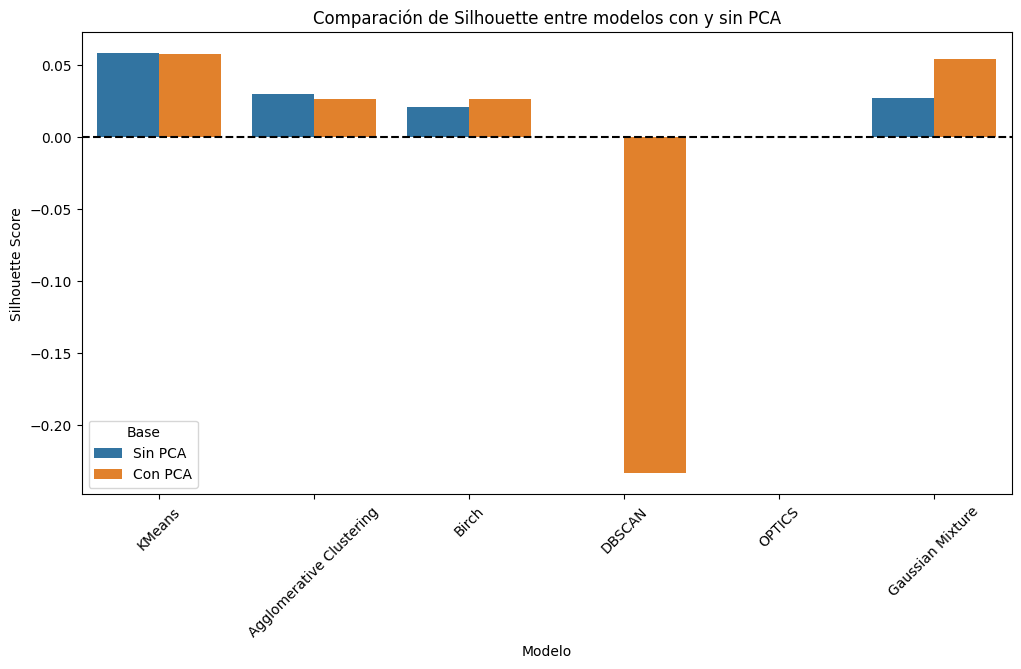

In [43]:
## 3.12 Visualización comparativa de Silhouette por modelo

plt.figure(figsize=(12,6))

sns.barplot(
    data=resultados_challenge,
    x="Modelo",
    y="Silhouette",
    hue="Base"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Comparación de Silhouette entre modelos con y sin PCA")
plt.xlabel("Modelo")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=45)
plt.legend(title="Base")
plt.show()

### Interpretación del Punto 3

En este punto se realizó un challenge entre distintos algoritmos de clustering, considerando modelos basados en distancia, modelos jerárquicos, modelos basados en densidad y un modelo probabilístico.

Antes de ejecutar el benchmarking final, se realizó una búsqueda preliminar del número de clusters mediante KMeans, probando distintos valores de K y seleccionando el mejor resultado según el índice Silhouette. Esta decisión permite evitar la elección arbitraria del número de clusters y alinear el experimento con una métrica objetiva de separación.

Posteriormente, se evaluaron los algoritmos KMeans, Agglomerative Clustering, Birch, DBSCAN, OPTICS y Gaussian Mixture sobre dos bases: una base sin PCA y una base con PCA. Esta comparación permite analizar si la reducción de dimensionalidad mejora la formación de clusters o si la estructura original normalizada conserva mejor la información necesaria para agrupar las viviendas.

Los modelos basados en distancia, como KMeans y Agglomerative Clustering, tienden a funcionar mejor cuando los grupos tienen formas relativamente compactas y separadas. En cambio, los modelos basados en densidad, como DBSCAN y OPTICS, buscan zonas de alta concentración de observaciones y pueden identificar ruido o puntos atípicos.

La comparación de los modelos se realiza utilizando principalmente el índice Silhouette, donde valores más altos indican clusters mejor separados. Además, se consideran métricas complementarias como Davies-Bouldin y Calinski-Harabasz para reforzar la evaluación del desempeño de los algoritmos.

## Punto 4. Evaluación, selección del modelo e interpretación con SalePrice

In [44]:
## 4.1 Revisión del ranking de modelos según métricas

ranking_silhouette

,Base,Modelo,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz,Comentario,Interpretación Silhouette
0,Sin PCA,KMeans,4,0,0.058021,3.010753,54.841981,Evaluado correctamente,Agrupamiento débil
6,Con PCA,KMeans,4,0,0.057861,3.511555,61.598243,Evaluado correctamente,Agrupamiento débil
11,Con PCA,Gaussian Mixture,4,0,0.054128,3.949710,58.037415,Evaluado correctamente,Agrupamiento débil
1,Sin PCA,Agglomerative Clustering,4,0,0.030149,4.366251,45.458644,Evaluado correctamente,Agrupamiento débil
5,Sin PCA,Gaussian Mixture,4,0,0.027472,4.560078,42.488790,Evaluado correctamente,Agrupamiento débil
8,Con PCA,Birch,4,0,0.026582,4.051319,50.937283,Evaluado correctamente,Agrupamiento débil
7,Con PCA,Agglomerative Clustering,4,0,0.026582,4.051319,50.937283,Evaluado correctamente,Agrupamiento débil
2,Sin PCA,Birch,4,0,0.020875,4.316465,45.361436,Evaluado correctamente,Agrupamiento débil
9,Con PCA,DBSCAN,2,1446,-0.233392,1.954834,1.788943,Evaluado correctamente,Agrupamiento débil o mal separado
3,Sin PCA,DBSCAN,1,1453,NaN,NaN,NaN,No evaluable: menos de 2 clusters,No evaluable


In [45]:
## 4.2 Selección automática del mejor modelo según Silhouette

mejor_modelo_info = ranking_silhouette.iloc[0]

mejor_base = mejor_modelo_info["Base"]
mejor_modelo = mejor_modelo_info["Modelo"]
mejor_silhouette = mejor_modelo_info["Silhouette"]
mejor_davies = mejor_modelo_info["Davies-Bouldin"]
mejor_calinski = mejor_modelo_info["Calinski-Harabasz"]
mejor_clusters = mejor_modelo_info["Clusters"]

print("Mejor base:", mejor_base)
print("Mejor modelo:", mejor_modelo)
print("Número de clusters:", mejor_clusters)
print("Silhouette:", mejor_silhouette)
print("Davies-Bouldin:", mejor_davies)
print("Calinski-Harabasz:", mejor_calinski)

Mejor base: Sin PCA
Mejor modelo: KMeans
Número de clusters: 4
Silhouette: 0.05802102455423731
Davies-Bouldin: 3.010753319261654
Calinski-Harabasz: 54.84198069677778


In [46]:
## 4.3 Función para reconstruir etiquetas del modelo seleccionado

def obtener_labels_modelo(X, modelo_nombre, n_clusters):
    """
    Reconstruye las etiquetas del modelo seleccionado.
    """

    if modelo_nombre == "KMeans":
        modelo = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = modelo.fit_predict(X)

    elif modelo_nombre == "Agglomerative Clustering":
        modelo = AgglomerativeClustering(n_clusters=n_clusters)
        labels = modelo.fit_predict(X)

    elif modelo_nombre == "Birch":
        modelo = Birch(n_clusters=n_clusters)
        labels = modelo.fit_predict(X)

    elif modelo_nombre == "DBSCAN":
        modelo = DBSCAN(eps=3, min_samples=5)
        labels = modelo.fit_predict(X)

    elif modelo_nombre == "OPTICS":
        modelo = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
        labels = modelo.fit_predict(X)

    elif modelo_nombre == "Gaussian Mixture":
        modelo = GaussianMixture(
            n_components=n_clusters,
            covariance_type="diag",
            reg_covar=1e-6,
            random_state=42
        )
        labels = modelo.fit_predict(X)

    else:
        raise ValueError("Modelo no reconocido")

    return labels

In [47]:
## 4.4 Obtener etiquetas del mejor modelo seleccionado

if mejor_base == "Sin PCA":
    X_mejor = X_sin_pca
    n_clusters_mejor = mejor_k_sin_pca
else:
    X_mejor = df_pca
    n_clusters_mejor = mejor_k_con_pca

labels_mejor_modelo = obtener_labels_modelo(
    X_mejor,
    mejor_modelo,
    n_clusters_mejor
)

print("Etiquetas generadas para el mejor modelo.")
print("Cantidad de observaciones:", len(labels_mejor_modelo))
print("Clusters identificados:", sorted(set(labels_mejor_modelo)))

Etiquetas generadas para el mejor modelo.
Cantidad de observaciones: 1458
Clusters identificados: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]


In [48]:
## 4.5 Crear base interpretativa con clusters y SalePrice

df_interpretacion = df_clean.copy()

df_interpretacion["Cluster"] = labels_mejor_modelo
df_interpretacion["SalePrice_Log"] = np.log1p(df_interpretacion["SalePrice"])

print("Dimensiones de la base interpretativa:", df_interpretacion.shape)
df_interpretacion[["SalePrice", "SalePrice_Log", "Cluster"]].head()

Dimensiones de la base interpretativa: (1458, 83)


,SalePrice,SalePrice_Log,Cluster
0,208500,12.247699,3
1,181500,12.109016,0
2,223500,12.317171,3
3,140000,11.849405,0
4,250000,12.429220,3


In [49]:
## 4.6 Análisis de SalePrice por cluster

analisis_precio_cluster = (
    df_interpretacion
    .groupby("Cluster")
    .agg(
        Total_viviendas=("SalePrice", "count"),
        Precio_promedio=("SalePrice", "mean"),
        Precio_mediano=("SalePrice", "median"),
        Precio_minimo=("SalePrice", "min"),
        Precio_maximo=("SalePrice", "max"),
        Calidad_promedio=("OverallQual", "mean"),
        Superficie_promedio=("GrLivArea", "mean")
    )
    .reset_index()
)

analisis_precio_cluster

,Cluster,Total_viviendas,Precio_promedio,Precio_mediano,Precio_minimo,Precio_maximo,Calidad_promedio,Superficie_promedio
0,0,775,147068.072258,140000.0,35311,475000,5.446452,1374.374194
1,1,74,105576.351351,102600.0,34900,200500,4.675676,1198.216216
2,2,37,105652.891892,101800.0,39300,198500,4.297297,1289.324324
3,3,572,241434.673077,220000.0,130000,755000,7.270979,1749.555944


In [50]:
## 4.7 Ordenar clusters por precio promedio

analisis_precio_cluster_ordenado = analisis_precio_cluster.sort_values(
    by="Precio_promedio",
    ascending=False
)

analisis_precio_cluster_ordenado

,Cluster,Total_viviendas,Precio_promedio,Precio_mediano,Precio_minimo,Precio_maximo,Calidad_promedio,Superficie_promedio
3,3,572,241434.673077,220000.0,130000,755000,7.270979,1749.555944
0,0,775,147068.072258,140000.0,35311,475000,5.446452,1374.374194
2,2,37,105652.891892,101800.0,39300,198500,4.297297,1289.324324
1,1,74,105576.351351,102600.0,34900,200500,4.675676,1198.216216


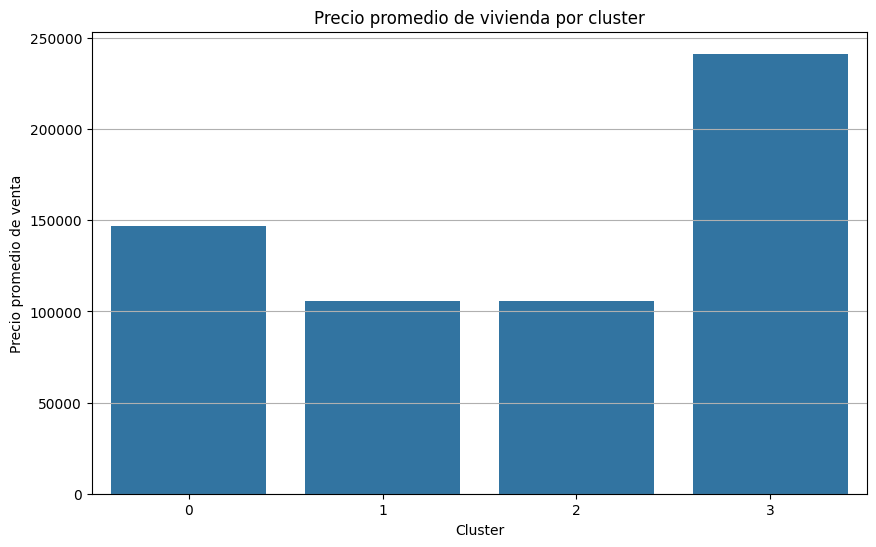

In [51]:
## 4.8 Visualización del precio promedio por cluster

plt.figure(figsize=(10,6))

sns.barplot(
    data=analisis_precio_cluster_ordenado,
    x="Cluster",
    y="Precio_promedio"
)

plt.title("Precio promedio de vivienda por cluster")
plt.xlabel("Cluster")
plt.ylabel("Precio promedio de venta")
plt.grid(axis="y")
plt.show()

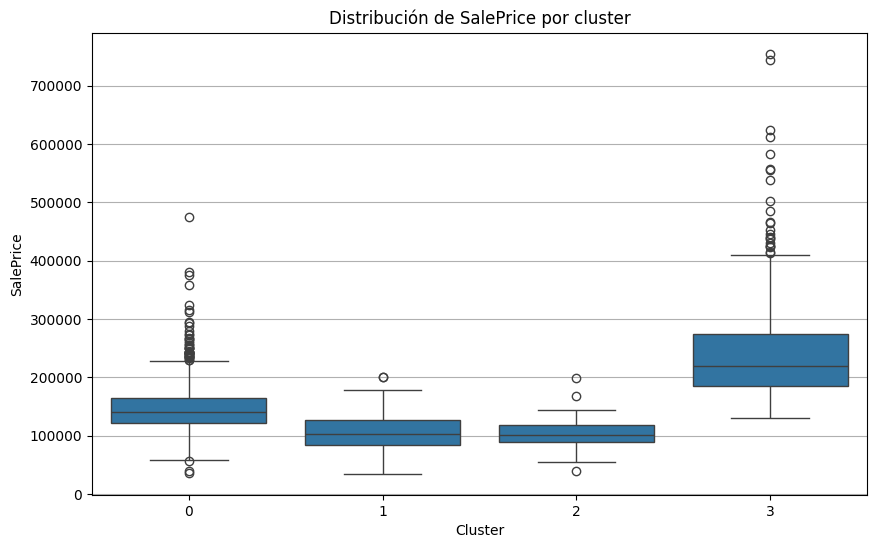

In [52]:
## 4.9 Distribución de SalePrice por cluster

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_interpretacion,
    x="Cluster",
    y="SalePrice"
)

plt.title("Distribución de SalePrice por cluster")
plt.xlabel("Cluster")
plt.ylabel("SalePrice")
plt.grid(axis="y")
plt.show()

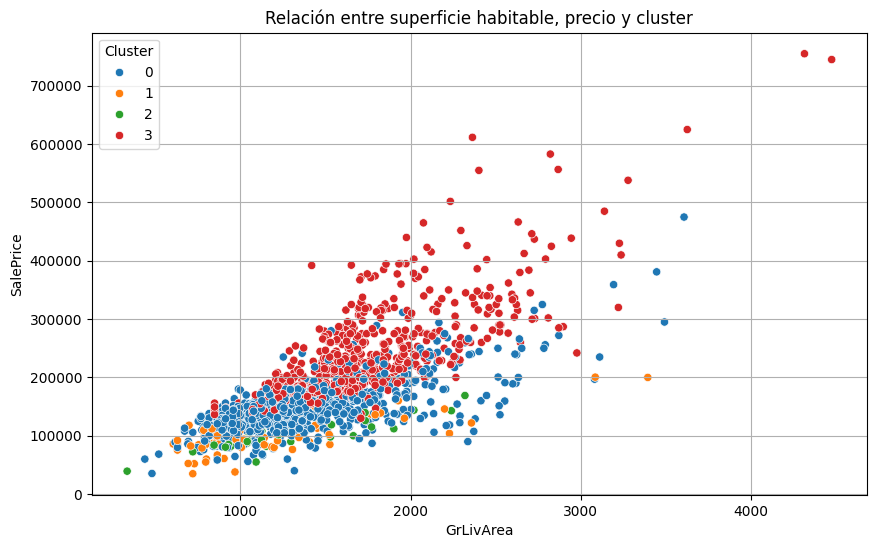

In [53]:
## 4.10 Relación entre calidad, superficie y cluster

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_interpretacion,
    x="GrLivArea",
    y="SalePrice",
    hue="Cluster",
    palette="tab10"
)

plt.title("Relación entre superficie habitable, precio y cluster")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

In [54]:
## 4.11 Resumen interpretativo del modelo seleccionado

print("Modelo seleccionado:", mejor_modelo)
print("Base utilizada:", mejor_base)
print("Número de clusters:", mejor_clusters)
print("Silhouette:", mejor_silhouette)
print("Davies-Bouldin:", mejor_davies)
print("Calinski-Harabasz:", mejor_calinski)

print("\nInterpretación general:")
if pd.isna(mejor_silhouette):
    print("El modelo seleccionado no es evaluable mediante Silhouette.")
elif mejor_silhouette < 0:
    print("El valor de Silhouette es negativo, lo que indica una estructura de clustering débil o mal separada.")
elif mejor_silhouette < 0.25:
    print("El valor de Silhouette indica una estructura de clustering débil.")
elif mejor_silhouette < 0.50:
    print("El valor de Silhouette indica una estructura de clustering moderada.")
else:
    print("El valor de Silhouette indica una estructura de clustering fuerte.")

Modelo seleccionado: KMeans
Base utilizada: Sin PCA
Número de clusters: 4
Silhouette: 0.05802102455423731
Davies-Bouldin: 3.010753319261654
Calinski-Harabasz: 54.84198069677778

Interpretación general:
El valor de Silhouette indica una estructura de clustering débil.


### Interpretación final del Punto 4

A partir del ranking de modelos, el algoritmo seleccionado fue KMeans aplicado sobre la base sin PCA, con 4 clusters. Esta selección se realizó porque fue el modelo con mejor valor de Silhouette dentro del benchmarking realizado.

El valor de Silhouette obtenido fue aproximadamente 0,058, lo que indica una estructura de clustering débil. Esto significa que los clusters no están claramente separados desde el punto de vista geométrico y que existe superposición entre grupos. Por lo tanto, el modelo no debe interpretarse como una segmentación definitiva, sino como una aproximación exploratoria.

Sin embargo, al incorporar la variable conocida SalePrice, que no fue utilizada durante el entrenamiento del clustering, se observan diferencias relevantes entre los grupos. El cluster 3 presenta el mayor precio promedio, mayor calidad promedio y mayor superficie habitable, por lo que puede interpretarse como un segmento de viviendas de mayor valor. El cluster 0 representa un segmento intermedio, mientras que los clusters 1 y 2 concentran viviendas de menor precio y menor calidad promedio.

El boxplot de SalePrice por cluster confirma esta lectura: el cluster 3 muestra una distribución de precios más alta, mientras que los clusters 1 y 2 se ubican en rangos más bajos. No obstante, también se observa superposición entre algunos grupos, lo que es consistente con el bajo valor de Silhouette.

En conclusión, el algoritmo muestra indicios de diferenciación parcial de las viviendas según su valor económico, calidad y superficie, pero la separación entre clusters es débil. Por ello, para mejorar el análisis se recomienda probar ajustes adicionales de hiperparámetros, nuevas variables derivadas, reducción dimensional alternativa o modelos de clustering con configuraciones más específicas.

## Punto 5. Publicación del cuaderno en GitHub

El cuaderno desarrollado fue cargado en un repositorio público de GitHub junto con el dataset utilizado. Esto permite asegurar la reproducibilidad del análisis, mantener trazabilidad del desarrollo y facilitar la revisión del código, los resultados y las interpretaciones obtenidas.

Repositorio utilizado: TRABAJO-U3-HOUSE-PRICES-CLUSTERING

Archivos principales:
- train.csv
- Sumativo_U3_HousePrices_Clustering_TeresaPainecura.ipynb
- README.md

## Conclusión

El desarrollo de esta actividad permitió aplicar técnicas de análisis no supervisado al dataset House Prices, con el objetivo de identificar agrupamientos naturales de viviendas a partir de sus características.

En primer lugar, se prepararon los datos mediante limpieza, tratamiento de valores faltantes, eliminación de valores atípicos, codificación One-Hot Encoding y normalización. Posteriormente, se construyeron dos representaciones del dataset: una base sin PCA y una base con PCA, conservando al menos el 90% de la varianza explicada acumulada.

Luego, se realizó un challenge entre distintos algoritmos de clustering, incluyendo modelos basados en distancia, jerárquicos, densidad y un modelo probabilístico. A partir de las métricas evaluadas, el mejor resultado correspondió a KMeans aplicado sobre la base sin PCA, con 4 clusters.

Sin embargo, el valor de Silhouette obtenido fue bajo, lo que indica que la separación geométrica entre clusters es débil. Esto significa que los grupos identificados no deben interpretarse como segmentos completamente definidos, sino como una aproximación exploratoria.

Al analizar los clusters con la variable conocida SalePrice, se observaron diferencias parciales entre los grupos. En particular, un cluster concentró viviendas de mayor precio promedio, mayor calidad y mayor superficie, mientras que otros clusters agruparon viviendas de menor valor. Esto sugiere que el modelo logró capturar cierta estructura económica del dataset, aunque con limitaciones.

En conclusión, el análisis no supervisado permitió explorar patrones internos en las viviendas, pero los resultados muestran que se requieren mejoras adicionales para obtener clusters más robustos. Entre las posibles mejoras se encuentran la creación de nuevas variables, una selección más cuidadosa de características, ajustes adicionales de hiperparámetros y la evaluación de otros enfoques de reducción dimensional o clustering.